In [1]:
from pathlib import Path
import os
import sys

folder = Path(os.getcwd())
if folder.parent not in sys.path:
    sys.path.append(str(folder.parent))
    
sys.path

['E:\\S3\\OT\\FADC',
 'c:\\Users\\Gautham\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip',
 'c:\\Users\\Gautham\\AppData\\Local\\Programs\\Python\\Python313\\DLLs',
 'c:\\Users\\Gautham\\AppData\\Local\\Programs\\Python\\Python313\\Lib',
 'c:\\Users\\Gautham\\AppData\\Local\\Programs\\Python\\Python313',
 '',
 'C:\\Users\\Gautham\\AppData\\Roaming\\Python\\Python313\\site-packages',
 'C:\\Users\\Gautham\\AppData\\Roaming\\Python\\Python313\\site-packages\\win32',
 'C:\\Users\\Gautham\\AppData\\Roaming\\Python\\Python313\\site-packages\\win32\\lib',
 'C:\\Users\\Gautham\\AppData\\Roaming\\Python\\Python313\\site-packages\\Pythonwin',
 'c:\\Users\\Gautham\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages',
 'e:\\S3\\RL\\New folder\\Generative-Reward-Decomposition-RL']

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pickle as pkl

with open('../results/metrics.pkl', 'rb') as f:
    metrics = pkl.load(f)

In [4]:
len(metrics)

9217

In [5]:
metrics[6000]

{'episode': 88,
 'gen_loss': 178.59841918945312,
 'l_rew': 178.5897216796875,
 'l_dyn': 0.005670568440109491,
 'l_reg': 0.003019512863829732,
 'returns': [{'predicted_return': 39.60898971557617, 'total_return': 28.0},
  {'predicted_return': 20.935436248779297, 'total_return': 18.0},
  {'predicted_return': 96.01310729980469, 'total_return': 78.0},
  {'predicted_return': 39.70036315917969, 'total_return': 24.0}]}

In [6]:
returns = []
for data in metrics:
    returns.extend(data['returns'])
    
len(returns)
returns[0]

{'predicted_return': -1.5161834955215454, 'total_return': 16.0}

In [7]:
start = 5000
limit = 300
predicted_returns = [data['predicted_return'] for data in returns][start:start + limit]
total_returns = [data['total_return'] for data in returns][start:start + limit]


TypeError: 'Text' object is not callable

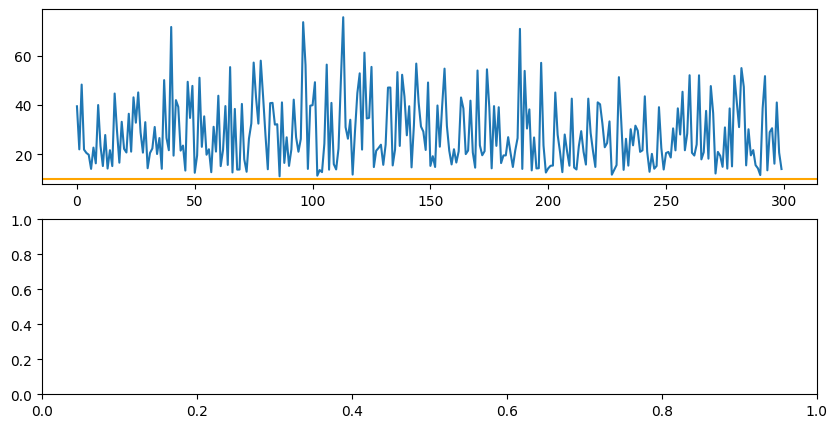

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

ax1.plot(range(len(predicted_returns)), predicted_returns)
ax1.axhline(y=min(total_returns), color='orange', label='min threshold')
ax1.set_title("Predicted Returns")
ax1.legend()

ax2.plot(range(len(total_returns)), total_returns)
ax2.axhline(y=min(total_returns), color='orange', label='min threshold')
ax2.set_title("Actual Returns")

plt.tight_layout()
plt.show()


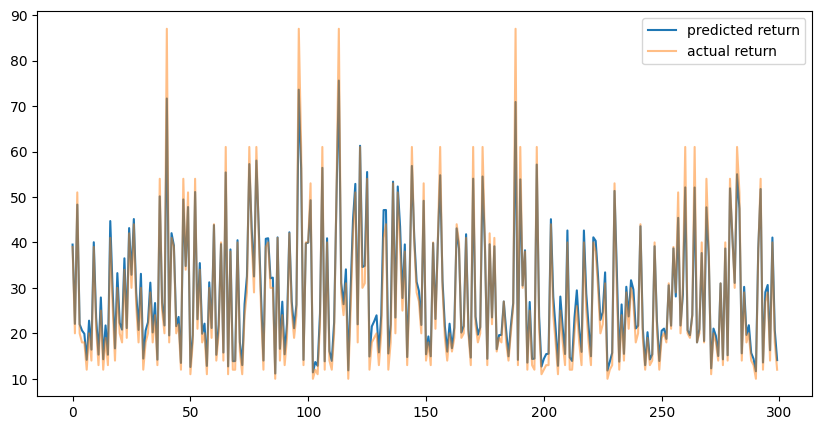

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(predicted_returns)), predicted_returns, label='predicted return')
plt.plot(range(len(total_returns)), total_returns, alpha=0.5, label='actual return')
plt.legend()
plt.show()